In [1]:
from pathlib import Path
import zipfile
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from tqdm import tqdm

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_DIR = PROJECT_ROOT / "data" / "exercise_7_4"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results" / "exercise_7_4_calibration"

DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TEST_ZIP = RAW_DIR / "test.zip"

MODEL_SPECS = {
    "pedestrian": {
        "label_column": "has_pedestrian",
        "model_path": MODELS_DIR / "has_pedestrian_resnet18.pt"
    },
    "traffic_light": {
        "label_column": "has_traffic_light",
        "model_path": MODELS_DIR / "has_traffic_light_resnet18.pt"
    },
    "vehicle": {
        "label_column": "has_vehicle",
        "model_path": MODELS_DIR / "has_vehicle_resnet18.pt"
    }
}

print("Project root:", PROJECT_ROOT)
print("Test zip exists:", TEST_ZIP.exists())

Project root: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3
Test zip exists: True


In [2]:
# extract and load test data

IMAGE_EXTENSIONS = ["*.png", "*.jpg", "*.jpeg"]

def unzip_once(zip_path, output_dir):
    output_dir.mkdir(parents=True, exist_ok=True)

    if any(output_dir.iterdir()):
        print(f"Already extracted, skipping: {output_dir}")
        return

    if not zip_path.exists():
        raise FileNotFoundError(f"Missing zip file: {zip_path}")

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(output_dir)

    print(f"Extracted {zip_path.name} to {output_dir}")


def find_images(folder):
    image_files = []
    for ext in IMAGE_EXTENSIONS:
        image_files.extend(folder.rglob(ext))
    return sorted(image_files)


def build_frame_to_image_map(folder):
    image_files = find_images(folder)
    frame_to_image = {}

    for image_path in image_files:
        number = "".join([c for c in image_path.stem if c.isdigit()])
        if number != "":
            frame_to_image[int(number)] = image_path

    return frame_to_image


TEST_DIR = DATA_DIR / "test"
unzip_once(TEST_ZIP, TEST_DIR)

csv_files = sorted(TEST_DIR.rglob("*.csv"))
if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file found inside extracted test data.")

test_df = pd.read_csv(csv_files[0])
frame_to_image = build_frame_to_image_map(TEST_DIR)

print("CSV:", csv_files[0])
print("Rows:", len(test_df))
print("Mapped images:", len(frame_to_image))

display(test_df.head())

Extracted test.zip to /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/data/exercise_7_4/test
CSV: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/data/exercise_7_4/test/test/labels.csv
Rows: 3600
Mapped images: 3600


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,False,15,0,35
1,10,True,False,True,299,0,116
2,20,True,False,True,298,0,307
3,30,True,False,True,297,0,258
4,40,True,False,True,297,0,249


In [4]:
# dataset class
class CarlaBinaryDataset(Dataset):
    def __init__(self, dataframe, frame_to_image, label_column, transform=None):
        self.df = dataframe.copy()
        self.frame_to_image = frame_to_image
        self.label_column = label_column
        self.transform = transform

        self.df = self.df[
            self.df["frame"].astype(int).isin(frame_to_image.keys())
        ].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        frame = int(row["frame"])

        image_path = self.frame_to_image[frame]
        image = Image.open(image_path).convert("RGB")

        label = torch.tensor(float(row[self.label_column]), dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label, frame

# load models
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


def create_model():
    model = models.resnet18(weights=None)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 1)
    return model


device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

loaded_models = {}

for model_name, spec in MODEL_SPECS.items():
    model = create_model().to(device)

    if not spec["model_path"].exists():
        raise FileNotFoundError(f"Missing model file: {spec['model_path']}")

    model.load_state_dict(torch.load(spec["model_path"], map_location=device))
    model.eval()

    loaded_models[model_name] = model
    print("Loaded model:", model_name)

Using device: mps
Loaded model: pedestrian
Loaded model: traffic_light
Loaded model: vehicle


In [5]:
# prediction function 
def get_predictions_for_model(model_name, batch_size=32):
    spec = MODEL_SPECS[model_name]
    label_column = spec["label_column"]
    model = loaded_models[model_name]

    dataset = CarlaBinaryDataset(
        dataframe=test_df,
        frame_to_image=frame_to_image,
        label_column=label_column,
        transform=image_transform
    )

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    rows = []

    with torch.no_grad():
        for images, labels, frames in tqdm(loader, desc=f"Predicting: {model_name}"):
            images = images.to(device)

            logits = model(images).squeeze(1)
            prob_positive = torch.sigmoid(logits)

            predictions = (prob_positive >= 0.5).int()
            labels_int = labels.int()

            confidence = torch.maximum(prob_positive, 1 - prob_positive)
            correct = predictions.cpu() == labels_int

            for frame, label, pred, prob, conf, corr in zip(
                frames.cpu().numpy(),
                labels_int.cpu().numpy(),
                predictions.cpu().numpy(),
                prob_positive.cpu().numpy(),
                confidence.cpu().numpy(),
                correct.cpu().numpy()
            ):
                rows.append({
                    "model_name": model_name,
                    "frame": int(frame),
                    "true_label": int(label),
                    "prediction": int(pred),
                    "probability_positive": float(prob),
                    "confidence": float(conf),
                    "correct": int(corr)
                })

    return pd.DataFrame(rows)

In [ ]:
# ECE function
def compute_ece(prediction_df, n_bins=10):
    confidences = prediction_df["confidence"].values
    correctness = prediction_df["correct"].values

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    ece = 0.0
    bin_rows = []

    for bin_idx in range(n_bins):
        lower = bin_edges[bin_idx]
        upper = bin_edges[bin_idx + 1]

        if bin_idx == n_bins - 1:
            in_bin = (confidences >= lower) & (confidences <= upper)
        else:
            in_bin = (confidences >= lower) & (confidences < upper)

        bin_size = np.sum(in_bin)

        if bin_size > 0:
            bin_accuracy = np.mean(correctness[in_bin])
            bin_confidence = np.mean(confidences[in_bin])
            bin_gap = abs(bin_accuracy - bin_confidence)
            bin_weight = bin_size / len(prediction_df)

            ece += bin_weight * bin_gap

            bin_rows.append({
                "bin": bin_idx + 1,
                "lower": lower,
                "upper": upper,
                "bin_size": int(bin_size),
                "accuracy": bin_accuracy,
                "confidence": bin_confidence,
                "gap": bin_gap
            })

    return ece, pd.DataFrame(bin_rows)

In [7]:
# compute ECE for all model
all_prediction_dfs = {}
all_ece_rows = {}
all_bin_dfs = {}

for model_name in MODEL_SPECS.keys():
    pred_df = get_predictions_for_model(model_name)

    ece, bin_df = compute_ece(pred_df, n_bins=10)

    all_prediction_dfs[model_name] = pred_df
    all_bin_dfs[model_name] = bin_df

    all_ece_rows[model_name] = {
        "model_name": model_name,
        "n_images": len(pred_df),
        "accuracy": round(pred_df["correct"].mean(), 4),
        "mean_confidence": round(pred_df["confidence"].mean(), 4),
        "ece": round(ece, 4)
    }

    pred_df.to_csv(RESULTS_DIR / f"exercise_7_4_predictions_{model_name}.csv", index=False)
    bin_df.to_csv(RESULTS_DIR / f"exercise_7_4_bins_{model_name}.csv", index=False)

ece_df = pd.DataFrame(all_ece_rows.values())

display(ece_df)

ece_path = RESULTS_DIR / "exercise_7_4_ece_results.csv"
ece_df.to_csv(ece_path, index=False)

print("Saved ECE results to:", ece_path)

Predicting: vehicle: 100%|██████████| 113/113 [00:19<00:00,  5.66it/s]


,model_name,n_images,accuracy,mean_confidence,ece
0,pedestrian,3600,0.8039,0.9573,0.1534
1,traffic_light,3600,0.2822,0.9756,0.6934
2,vehicle,3600,0.7581,0.8632,0.1168


Saved ECE results to: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/results/exercise_7_4_calibration/exercise_7_4_ece_results.csv


# Interpretation of results from above table
1. For Pedestrian model: Confidence is much higher than accuracy, so it looks overconfident.
2. For Traffic Light: This is the worst calibrated model. It is strongly overconfident.
3. For Vehicle model: This is also overconfident, but less severe than traffic light.

# Overall:

All three models have confidence higher than accuracy, so the initial pattern is overconfidence.
This proves that calibration compares confidence vs. empirical accuracy using bins and ECE.

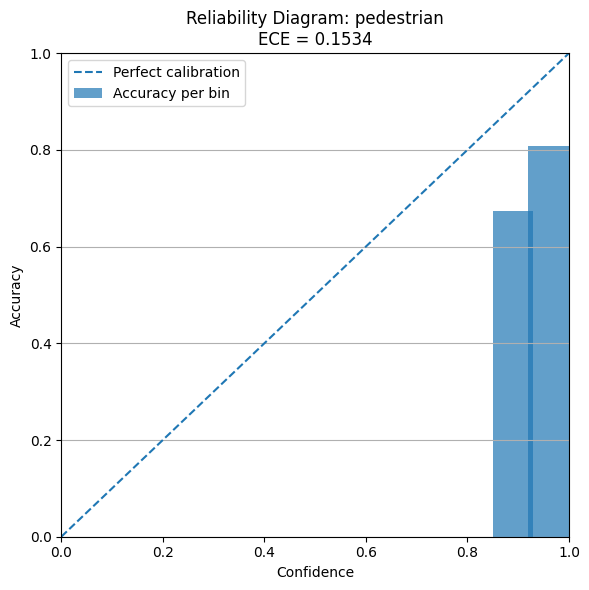

Saved: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/results/exercise_7_4_calibration/exercise_7_4_reliability_diagram_pedestrian.png


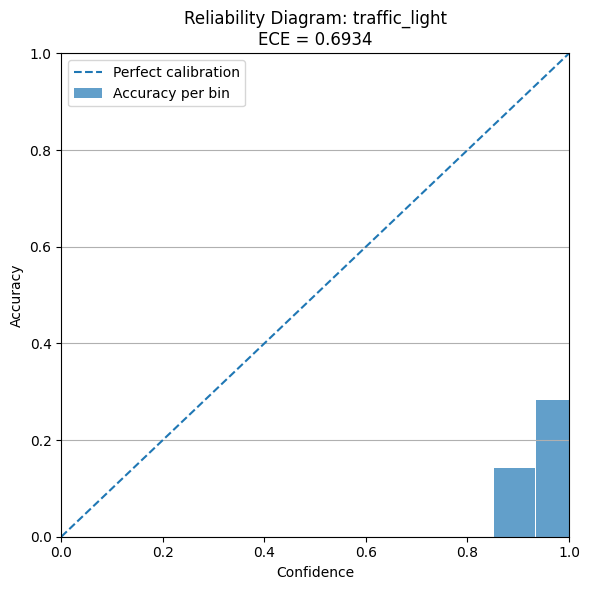

Saved: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/results/exercise_7_4_calibration/exercise_7_4_reliability_diagram_traffic_light.png


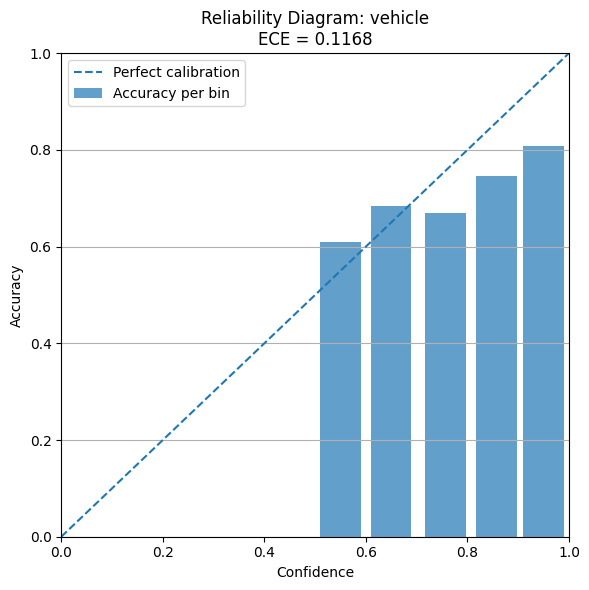

Saved: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/results/exercise_7_4_calibration/exercise_7_4_reliability_diagram_vehicle.png


In [8]:
# 7.4.2: Plot reliability diagram (confidence vs. accuracy) for each model.
import matplotlib.pyplot as plt

def plot_reliability_diagram(model_name, bin_df, ece_value, save_path=None):
    plt.figure(figsize=(6, 6))

    # Perfect calibration diagonal
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

    # Reliability bars/points
    plt.bar(
        bin_df["confidence"],
        bin_df["accuracy"],
        width=0.08,
        alpha=0.7,
        label="Accuracy per bin"
    )

    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(f"Reliability Diagram: {model_name}\nECE = {ece_value:.4f}")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(axis="y")
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()


for model_name in MODEL_SPECS.keys():
    ece_value = ece_df[ece_df["model_name"] == model_name]["ece"].values[0]
    bin_df = all_bin_dfs[model_name]

    save_path = RESULTS_DIR / f"exercise_7_4_reliability_diagram_{model_name}.png"

    plot_reliability_diagram(
        model_name=model_name,
        bin_df=bin_df,
        ece_value=ece_value,
        save_path=save_path
    )

    print("Saved:", save_path)

# Final conclusion
All three models are overconfident overall.
The pattern holds across all three models, but not with the same strength.
The traffic light model is the most miscalibrated, while the vehicle model is the least miscalibrated.
This means the predicted confidence values should not be trusted directly for safety decisions without calibration.

In [ ]:
# 7.5: Tempreture Scaling - Optimize tempreture T on validation set
VALIDATION_ZIP = RAW_DIR / "validation.zip"
VALIDATION_DIR = DATA_DIR / "validation"

unzip_once(VALIDATION_ZIP, VALIDATION_DIR)

validation_csv_files = sorted(VALIDATION_DIR.rglob("*.csv"))
if len(validation_csv_files) == 0:
    raise FileNotFoundError("No CSV file found inside extracted validation data.")

validation_df = pd.read_csv(validation_csv_files[0])
validation_frame_to_image = build_frame_to_image_map(VALIDATION_DIR)

print("Validation CSV:", validation_csv_files[0])
print("Validation rows:", len(validation_df))
print("Mapped validation images:", len(validation_frame_to_image))

display(validation_df.head())

Extracted validation.zip to /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/data/exercise_7_4/validation
Validation CSV: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/data/exercise_7_4/validation/validation/labels.csv
Validation rows: 3600
Mapped validation images: 3600


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,True,False,0,178,10
1,10,True,False,False,347,0,2
2,20,True,False,False,347,0,0
3,30,True,False,False,347,0,0
4,40,True,False,False,347,0,0


In [10]:
# validate logits function
def get_logits_and_labels(model_name, dataframe, frame_to_image, batch_size=32):
    spec = MODEL_SPECS[model_name]
    label_column = spec["label_column"]
    model = loaded_models[model_name]

    dataset = CarlaBinaryDataset(
        dataframe=dataframe,
        frame_to_image=frame_to_image,
        label_column=label_column,
        transform=image_transform
    )

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    all_logits = []
    all_labels = []

    model.eval()

    with torch.no_grad():
        for images, labels, frames in tqdm(loader, desc=f"Logits: {model_name}"):
            images = images.to(device)

            logits = model(images).squeeze(1)

            all_logits.extend(logits.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    logits_tensor = torch.tensor(all_logits, dtype=torch.float32)
    labels_tensor = torch.tensor(all_labels, dtype=torch.float32)

    return logits_tensor, labels_tensor

In [11]:
# NLL function for binary tempreture scaling
bce_loss = nn.BCEWithLogitsLoss()

def compute_nll_for_temperature(logits, labels, temperature):
    scaled_logits = logits / temperature
    loss = bce_loss(scaled_logits, labels)
    return loss.item()

In [12]:
# Optimize T using grid search
temperature_values = np.round(np.arange(0.5, 3.01, 0.1), 1)

temperature_rows = []
best_temperatures = {}

for model_name in MODEL_SPECS.keys():
    val_logits, val_labels = get_logits_and_labels(
        model_name=model_name,
        dataframe=validation_df,
        frame_to_image=validation_frame_to_image,
        batch_size=32
    )

    best_T = None
    best_nll = float("inf")

    for T in temperature_values:
        nll = compute_nll_for_temperature(
            logits=val_logits,
            labels=val_labels,
            temperature=T
        )

        temperature_rows.append({
            "model_name": model_name,
            "temperature": T,
            "validation_nll": nll
        })

        if nll < best_nll:
            best_nll = nll
            best_T = T

    best_temperatures[model_name] = best_T

    print(f"{model_name}: best T = {best_T}, best validation NLL = {best_nll:.4f}")

temperature_search_df = pd.DataFrame(temperature_rows)

display(temperature_search_df.head())
print("Best temperatures:", best_temperatures)

temperature_search_path = RESULTS_DIR / "exercise_7_5_temperature_search.csv"
temperature_search_df.to_csv(temperature_search_path, index=False)

best_temperature_df = pd.DataFrame([
    {
        "model_name": model_name,
        "best_temperature": best_T
    }
    for model_name, best_T in best_temperatures.items()
])

display(best_temperature_df)

best_temperature_path = RESULTS_DIR / "exercise_7_5_best_temperatures.csv"
best_temperature_df.to_csv(best_temperature_path, index=False)

print("Saved temperature search to:", temperature_search_path)
print("Saved best temperatures to:", best_temperature_path)

Logits: pedestrian: 100%|██████████| 113/113 [00:17<00:00,  6.34it/s]


pedestrian: best T = 2.8, best validation NLL = 0.5656


Logits: traffic_light: 100%|██████████| 113/113 [00:19<00:00,  5.81it/s]


traffic_light: best T = 3.0, best validation NLL = 1.4122


Logits: vehicle: 100%|██████████| 113/113 [00:19<00:00,  5.71it/s]

vehicle: best T = 2.2, best validation NLL = 0.5928


,model_name,temperature,validation_nll
0,pedestrian,0.5,1.501848
1,pedestrian,0.6,1.257603
2,pedestrian,0.7,1.087387
3,pedestrian,0.8,0.964203
4,pedestrian,0.9,0.872737


Best temperatures: {'pedestrian': np.float64(2.8), 'traffic_light': np.float64(3.0), 'vehicle': np.float64(2.2)}


,model_name,best_temperature
0,pedestrian,2.8
1,traffic_light,3.0
2,vehicle,2.2


Saved temperature search to: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/results/exercise_7_4_calibration/exercise_7_5_temperature_search.csv
Saved best temperatures to: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/results/exercise_7_4_calibration/exercise_7_5_best_temperatures.csv


Since all values are greater than 1, temperature scaling will soften the logits and reduce overconfidence.
This tells us that, temperature scaling freezes the trained model and fits one T by minimizing validation NLL.

In [14]:
# Compute ECE after temperature scaling
def get_predictions_from_logits(model_name, logits, labels, temperature=1.0):
    scaled_logits = logits / temperature
    prob_positive = torch.sigmoid(scaled_logits)

    predictions = (prob_positive >= 0.5).int()
    labels_int = labels.int()

    confidence = torch.maximum(prob_positive, 1 - prob_positive)
    correct = predictions == labels_int

    pred_df = pd.DataFrame({
        "model_name": model_name,
        "true_label": labels_int.numpy(),
        "prediction": predictions.numpy(),
        "probability_positive": prob_positive.numpy(),
        "confidence": confidence.numpy(),
        "correct": correct.numpy().astype(int)
    })

    return pred_df

# compare ECE before and after scaling
calibration_rows = []
scaled_prediction_dfs = {}
scaled_bin_dfs = {}

for model_name in MODEL_SPECS.keys():
    # Get logits on test set
    test_logits, test_labels = get_logits_and_labels(
        model_name=model_name,
        dataframe=test_df,
        frame_to_image=frame_to_image,
        batch_size=32
    )

    best_T = float(best_temperatures[model_name])

    # Before scaling: T = 1.0
    before_df = get_predictions_from_logits(
        model_name=model_name,
        logits=test_logits,
        labels=test_labels,
        temperature=1.0
    )

    ece_before, bins_before = compute_ece(before_df, n_bins=10)

    # After scaling: T = best_T
    after_df = get_predictions_from_logits(
        model_name=model_name,
        logits=test_logits,
        labels=test_labels,
        temperature=best_T
    )

    ece_after, bins_after = compute_ece(after_df, n_bins=10)

    scaled_prediction_dfs[model_name] = after_df
    scaled_bin_dfs[model_name] = bins_after

    calibration_rows.append({
        "model_name": model_name,
        "best_temperature": best_T,
        "accuracy_before": round(before_df["correct"].mean(), 4),
        "accuracy_after": round(after_df["correct"].mean(), 4),
        "mean_confidence_before": round(before_df["confidence"].mean(), 4),
        "mean_confidence_after": round(after_df["confidence"].mean(), 4),
        "ece_before": round(ece_before, 4),
        "ece_after": round(ece_after, 4),
        "ece_change": round(ece_after - ece_before, 4)
    })

    after_df.to_csv(
        RESULTS_DIR / f"exercise_7_5_scaled_predictions_{model_name}.csv",
        index=False
    )

    bins_after.to_csv(
        RESULTS_DIR / f"exercise_7_5_scaled_bins_{model_name}.csv",
        index=False
    )

calibration_comparison_df = pd.DataFrame(calibration_rows)

display(calibration_comparison_df)

comparison_path = RESULTS_DIR / "exercise_7_5_ece_before_after_temperature_scaling.csv"
calibration_comparison_df.to_csv(comparison_path, index=False)

print("Saved ECE comparison to:", comparison_path)

Logits: vehicle: 100%|██████████| 113/113 [00:19<00:00,  5.90it/s]


,model_name,best_temperature,accuracy_before,accuracy_after,mean_confidence_before,mean_confidence_after,ece_before,ece_after,ece_change
0,pedestrian,2.8,0.8039,0.8039,0.9573,0.7591,0.1534,0.0457,-0.1077
1,traffic_light,3.0,0.2822,0.2822,0.9756,0.7939,0.6934,0.5117,-0.1817
2,vehicle,2.2,0.7581,0.7581,0.8632,0.7248,0.1168,0.0335,-0.0833


Saved ECE comparison to: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/results/exercise_7_4_calibration/exercise_7_5_ece_before_after_temperature_scaling.csv


# Final conclusion
Temperature scaling improved calibration for all three models.
ECE decreased for every model.
Accuracy stayed the same before and after scaling.

Mean confidence decreased for all models:
pedestrian: 0.9573 > 0.7591
traffic light: 0.9756 > 0.7939
vehicle: 0.8632 > 0.7248

This shows that the models were overconfident before scaling.
Temperature scaling reduced overconfidence without changing classification accuracy.
The traffic light model is still poorly calibrated after scaling, but it improved compared to before.

In [15]:
# Exercise 7.6.1: Cost-optimal decision for uncalibrated pedestrian model

CFN = 100
CFP = 1

TAU_STANDARD = 0.5
TAU_STAR = 1 / 101   # approximately 0.0099

MODEL_TO_USE = "pedestrian"

# Get test logits and labels for pedestrian model
test_logits, test_labels = get_logits_and_labels(
    model_name=MODEL_TO_USE,
    dataframe=test_df,
    frame_to_image=frame_to_image,
    batch_size=32
)

def compute_cost_loss_from_logits(logits, labels, threshold, temperature=1.0):
    # Apply temperature scaling if needed
    scaled_logits = logits / temperature
    
    # Convert logits to probability of pedestrian present
    probabilities = torch.sigmoid(scaled_logits)
    
    # Apply threshold
    predictions = (probabilities >= threshold).int()
    labels_int = labels.int()
    
    # False negatives: true pedestrian = 1, predicted no pedestrian = 0
    false_negatives = ((labels_int == 1) & (predictions == 0)).sum().item()
    
    # False positives: true no pedestrian = 0, predicted pedestrian = 1
    false_positives = ((labels_int == 0) & (predictions == 1)).sum().item()
    
    total_loss = CFN * false_negatives + CFP * false_positives
    
    return {
        "threshold": threshold,
        "temperature": temperature,
        "false_negatives": false_negatives,
        "false_positives": false_positives,
        "total_loss": total_loss
    }


uncalibrated_tau_05 = compute_cost_loss_from_logits(
    logits=test_logits,
    labels=test_labels,
    threshold=TAU_STANDARD,
    temperature=1.0
)

uncalibrated_tau_star = compute_cost_loss_from_logits(
    logits=test_logits,
    labels=test_labels,
    threshold=TAU_STAR,
    temperature=1.0
)

uncalibrated_results_df = pd.DataFrame([
    {
        "model": "uncalibrated",
        "threshold_name": "tau = 0.5",
        **uncalibrated_tau_05
    },
    {
        "model": "uncalibrated",
        "threshold_name": "tau* = 0.0099",
        **uncalibrated_tau_star
    }
])

display(uncalibrated_results_df)

Logits: pedestrian: 100%|██████████| 113/113 [00:18<00:00,  6.21it/s]


,model,threshold_name,threshold,temperature,false_negatives,false_positives,total_loss
0,uncalibrated,tau = 0.5,0.500000,1.0,706,0,70600
1,uncalibrated,tau* = 0.0099,0.009901,1.0,0,2868,2868


# Interpretation for 7.6.1
For the uncalibrated pedestrian model at τ = 0.5:
False negatives = 706, False positives = 0, Total loss = 70600
This is very high because missing pedestrians has cost 100.

At the cost-optimal threshold τ* = 0.0099:
False negatives = 0, False positives = 2868, Total loss = 2868
This is much lower because the model brakes more often and avoids missing pedestrians.

Conclusion:
τ* = 0.0099 is much better than τ = 0.5 for the uncalibrated model.
This makes sense because false negatives are much more expensive than false positives.

In [16]:
# Exercise 7.6.2: Cost-optimal decision for calibrated pedestrian model

BEST_T_PEDESTRIAN = float(best_temperatures["pedestrian"])

calibrated_tau_05 = compute_cost_loss_from_logits(
    logits=test_logits,
    labels=test_labels,
    threshold=TAU_STANDARD,
    temperature=BEST_T_PEDESTRIAN
)

calibrated_tau_star = compute_cost_loss_from_logits(
    logits=test_logits,
    labels=test_labels,
    threshold=TAU_STAR,
    temperature=BEST_T_PEDESTRIAN
)

calibrated_results_df = pd.DataFrame([
    {
        "model": "calibrated",
        "threshold_name": "tau = 0.5",
        **calibrated_tau_05
    },
    {
        "model": "calibrated",
        "threshold_name": "tau* = 0.0099",
        **calibrated_tau_star
    }
])

display(calibrated_results_df)

,model,threshold_name,threshold,temperature,false_negatives,false_positives,total_loss
0,calibrated,tau = 0.5,0.500000,2.8,706,0,70600
1,calibrated,tau* = 0.0099,0.009901,2.8,0,2894,2894


In [17]:
# Exercise 7.6.3: Final 2x2 table

all_cost_results_df = pd.concat(
    [uncalibrated_results_df, calibrated_results_df],
    ignore_index=True
)

display(all_cost_results_df)

# 2 x 2 table: rows = uncalibrated/calibrated, columns = tau = 0.5 / tau*
loss_table = all_cost_results_df.pivot(
    index="model",
    columns="threshold_name",
    values="total_loss"
)

display(loss_table)

# Save results
cost_results_path = RESULTS_DIR / "exercise_7_6_cost_decision_results.csv"
loss_table_path = RESULTS_DIR / "exercise_7_6_cost_decision_2x2_table.csv"

all_cost_results_df.to_csv(cost_results_path, index=False)
loss_table.to_csv(loss_table_path)

print("Saved full results to:", cost_results_path)
print("Saved 2x2 table to:", loss_table_path)

# Find best combination
best_row = all_cost_results_df.loc[all_cost_results_df["total_loss"].idxmin()]

print("Lowest total loss:")
print(best_row)

,model,threshold_name,threshold,temperature,false_negatives,false_positives,total_loss
0,uncalibrated,tau = 0.5,0.500000,1.0,706,0,70600
1,uncalibrated,tau* = 0.0099,0.009901,1.0,0,2868,2868
2,calibrated,tau = 0.5,0.500000,2.8,706,0,70600
3,calibrated,tau* = 0.0099,0.009901,2.8,0,2894,2894


threshold_name,tau = 0.5,tau* = 0.0099
model,,
calibrated,70600,2894
uncalibrated,70600,2868


Saved full results to: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/results/exercise_7_4_calibration/exercise_7_6_cost_decision_results.csv
Saved 2x2 table to: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/results/exercise_7_4_calibration/exercise_7_6_cost_decision_2x2_table.csv
Lowest total loss:
model               uncalibrated
threshold_name     tau* = 0.0099
threshold               0.009901
temperature                  1.0
false_negatives                0
false_positives             2868
total_loss                  2868
Name: 1, dtype: object


# Final conclusion
The lowest total loss is from the uncalibrated model with τ* = 0.0099.
Lowest loss: 2868
The standard threshold τ = 0.5 performs badly because it misses all 706 pedestrian-positive cases.
Since false negatives cost 100, missing pedestrians is much more expensive than unnecessary braking.
The cost-optimal threshold reduces loss because it avoids false negatives, even though it creates many false positives.
Calibration improved ECE, but here the threshold choice had the biggest effect on total cost.

# Exercise 7.7: Tracing Overconfidence Through the Safety Analysis

# 1. Causal scenario

* Existing hazard: vehicle fails to brake for a pedestrian
* Existing UCA: planner does not command braking while a pedestrian is in the path
* New causal scenario:

  * The pedestrian classifier gives a false negative
  * It predicts “no pedestrian” even when a pedestrian is present.
  * The prediction is also high confidence, so the planner treats it as reliable.
  * Because the model seems confident, no low-confidence fallback is triggered.
  * Result: the vehicle continues instead of braking.

# 2. Safety constraints

* Model-level calibration constraint:

  * The pedestrian classifier must be calibrated well enough for safety decisions.
  * I set the constraint as: ECE should be ≤ 0.05 after calibration.
  * Reason: confidence is used by the downstream planner, so high-confidence false negatives are dangerous.

* System-level planner constraint:

  * The planner must not rely only on the standard `τ = 0.5` threshold.
  * For pedestrian detection, it should use the cost-optimal threshold `τ* ≈ 0.0099`.
  * If confidence is low or the input looks unreliable, the planner should trigger fallback, slow down, or brake safely.

# 3. Verification

* The model-level constraint is verified using ECE before and after temperature scaling.
* My pedestrian model results:

  * ECE before scaling: `0.1534`
  * ECE after scaling: `0.0457`
* Since `0.0457 ≤ 0.05`, the calibrated pedestrian model meets my ECE constraint.
* This evidence comes directly from Exercise 7.4 and 7.5.

# 4. Residual risk

* Even with perfect calibration, risk remains.
* Calibration only makes probabilities more trustworthy on average.
* It does not guarantee that every individual prediction is correct.
* A calibrated model can still produce a false negative.
* Calibration also may break under distribution shift or adversarial inputs.
* Therefore, calibration alone does not close the scenario.
* A system-level fallback is still required.